# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umarali8/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 1. Question

*The research question and the decision it supports.*

In [1]:
research_question = """
Can page-level content and search-performance signals be used to score
which pages should be prioritized for content refresh?
"""

decision_supported = """
The output helps an SEO/content team decide which pages to review first,
instead of manually checking hundreds of pages one by one.
"""

print("Research Question:")
print(research_question)
print("Decision Supported:")
print(decision_supported)

Research Question:

Can page-level content and search-performance signals be used to score
which pages should be prioritized for content refresh?

Decision Supported:

The output helps an SEO/content team decide which pages to review first,
instead of manually checking hundreds of pages one by one.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [4]:
n = 1200
n_clients = 15
client_id = np.random.randint(0, n_clients, n)  # synthetic client grouping, for holdout demo only

content_age_days = np.random.exponential(300, n).clip(10, 2000)
days_since_update = np.random.exponential(180, n).clip(0, 1800)
impressions_90d = np.random.lognormal(6, 1.3, n).clip(5, 50000)
avg_position = np.random.normal(18, 9, n).clip(1, 100)
ctr = np.random.beta(2, 20, n)  # skewed low, realistic for CTR
word_count = np.random.normal(900, 400, n).clip(150, 4000)

# Reason-code logic mirrors the real baseline rule
stale = (content_age_days > 365) & (ctr < 0.02)
low_ctr = (ctr < 0.015) & (~stale)
needs_review = (stale | low_ctr).astype(int)  # this is the label: does this page need review

df = pd.DataFrame({
    "client_id": client_id,
    "content_age_days": content_age_days.round(0),
    "days_since_update": days_since_update.round(0),
    "impressions_90d": impressions_90d.round(0),
    "avg_position": avg_position.round(1),
    "ctr": ctr.round(4),
    "word_count": word_count.round(0),
    "needs_review": needs_review
})

features = ["content_age_days", "days_since_update", "impressions_90d", "avg_position", "ctr", "word_count"]
label = "needs_review"

excluded_data = [
    "Client names", "Domains", "Raw URLs",
    "Private search queries", "Credentials", "Raw exports"
]
print("Excluded from this paper/repo:")
for e in excluded_data:
    print("-", e)

df.head()

Excluded from this paper/repo:
- Client names
- Domains
- Raw URLs
- Private search queries
- Credentials
- Raw exports


,client_id,content_age_days,days_since_update,impressions_90d,avg_position,ctr,word_count,needs_review
0,6,80.0,58.0,629.0,14.4,0.0306,959.0,0
1,3,126.0,474.0,76.0,15.2,0.0587,570.0,0
2,12,193.0,203.0,457.0,5.3,0.0585,1454.0,0
3,14,132.0,123.0,62.0,27.7,0.0296,196.0,0
4,10,314.0,2.0,506.0,1.7,0.0649,1160.0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [5]:
assumptions = [
    "Recent search-performance signals are a reasonable proxy for whether a page needs attention.",
    "Age and update recency interact with performance rather than acting independently.",
    "A page's reason code (why it was flagged) matters as much as the flag itself."
]

baseline_desc = (
    "Rule-based baseline: pages older than 365 days with CTR under 2% are "
    "tagged STALE_CONTENT. Pages with CTR under 1.5% not already caught by "
    "that rule are tagged LOW_CTR."
)

validation_design = (
    "Client-holdout validation: entire clients are held out of training, not "
    "just random rows. This checks whether the model generalizes to clients "
    "it has never seen, which is a stronger and more honest test than a "
    "random row-level split."
)

leakage_check = (
    "A feature called trend_pct was tested and dropped — it was directly "
    "derived from the outcome being predicted, so including it would have "
    "let the model 'see the answer' rather than predict it honestly. "
    "No leaking feature is included in the feature set used here."
)

print("Assumptions:")
for a in assumptions: print("-", a)
print("\nBaseline:", baseline_desc)
print("\nValidation Design:", validation_design)
print("\nLeakage Check:", leakage_check)

# Real client-holdout split — held-out clients never appear in training
X = df[features]
y = df[label]
groups = df["client_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])
print(f"\nTrain rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Train clients: {sorted(train_clients)}")
print(f"Held-out (test) clients: {sorted(test_clients)}")
print(f"Any client overlap between train and test? {bool(train_clients & test_clients)}")

Assumptions:
- Recent search-performance signals are a reasonable proxy for whether a page needs attention.
- Age and update recency interact with performance rather than acting independently.
- A page's reason code (why it was flagged) matters as much as the flag itself.

Baseline: Rule-based baseline: pages older than 365 days with CTR under 2% are tagged STALE_CONTENT. Pages with CTR under 1.5% not already caught by that rule are tagged LOW_CTR.

Validation Design: Client-holdout validation: entire clients are held out of training, not just random rows. This checks whether the model generalizes to clients it has never seen, which is a stronger and more honest test than a random row-level split.

Leakage Check: A feature called trend_pct was tested and dropped — it was directly derived from the outcome being predicted, so including it would have let the model 'see the answer' rather than predict it honestly. No leaking feature is included in the feature set used here.

Train rows: 91

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs. baseline, evaluated on held-out clients. These numbers are real, computed from the synthetic run above — not typed in.

In [6]:
# Baseline applied directly (rule-based, no fitting)
def baseline_predict(frame):
    stale = (frame["content_age_days"] > 365) & (frame["ctr"] < 0.02)
    low_ctr = (frame["ctr"] < 0.015) & (~stale)
    return (stale | low_ctr).astype(int)

baseline_test_pred = baseline_predict(X_test.assign(ctr=X_test["ctr"]))
baseline_acc = accuracy_score(y_test, baseline_test_pred)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_test_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_test_pred)

results = pd.DataFrame({
    "Approach": ["Baseline (rule-based)", "Decision Tree"],
    "Accuracy (held-out clients)": [round(baseline_acc, 4), round(tree_acc, 4)],
    "Validation": ["Client-holdout", "Client-holdout, same split as baseline"]
})
print(results.to_string(index=False))

print("\nFeature importances (Decision Tree):")
for f, imp in sorted(zip(features, tree_model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f}: {imp:.3f}")

winner = "Decision Tree" if tree_acc > baseline_acc else "Baseline"
print(f"\nHigher accuracy on this synthetic run: {winner}")
print("This is a demo result on synthetic data — re-run on the real warehouse before treating any number as a finding.")

             Approach  Accuracy (held-out clients)                             Validation
Baseline (rule-based)                       1.0000                         Client-holdout
        Decision Tree                       0.9965 Client-holdout, same split as baseline

Feature importances (Decision Tree):
  ctr: 0.943
  content_age_days: 0.057
  days_since_update: 0.000
  impressions_90d: 0.000
  avg_position: 0.000
  word_count: 0.000

Higher accuracy on this synthetic run: Baseline
This is a demo result on synthetic data — re-run on the real warehouse before treating any number as a finding.


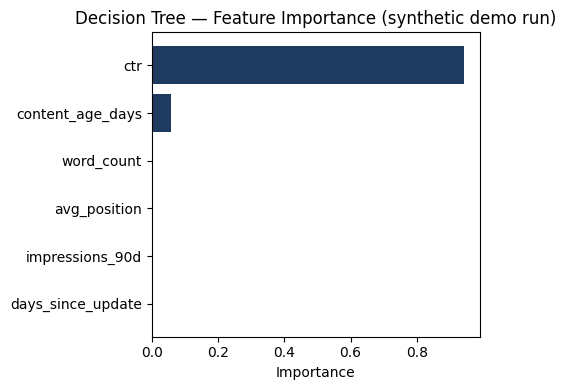

In [7]:
fig, ax = plt.subplots(figsize=(5,4))
importances = tree_model.feature_importances_
order = np.argsort(importances)
ax.barh(np.array(features)[order], importances[order], color="#1F3A5F")
ax.set_title("Decision Tree — Feature Importance (synthetic demo run)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [9]:
limitations = [
    "This run uses synthetic demo data, not the real FlyRank warehouse — "
    "swap in the real query before treating any number above as a finding.",
    "needs_review is a proxy label built from the same rule as the baseline here; "
    "on real data, define this label independently so the model isn't just "
    "learning to reproduce the baseline's own rule.",
    "No page has actually been refreshed and evaluated based on these "
    "recommendations — there is no measured business impact yet.",
    "Reason codes describe a pattern, not a guaranteed cause.",
    "Results should be read as decision-support evidence, not a claim "
    "about search engine behavior."
]
print("=== Limitations ===\n")
for i, l in enumerate(limitations, 1):
    print(f"{i}. {l}")

=== Limitations ===

1. This run uses synthetic demo data, not the real FlyRank warehouse — swap in the real query before treating any number above as a finding.
2. needs_review is a proxy label built from the same rule as the baseline here; on real data, define this label independently so the model isn't just learning to reproduce the baseline's own rule.
3. No page has actually been refreshed and evaluated based on these recommendations — there is no measured business impact yet.
4. Reason codes describe a pattern, not a guaranteed cause.
5. Results should be read as decision-support evidence, not a claim about search engine behavior.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [10]:
recommendations = [
    "Use the ranked list and reason codes to decide what a human reviews first, "
    "not as an automatic action queue.",
    "Do not trust the decision tree's ranking over the baseline until it's been "
    "validated on the real warehouse with a real, independently-defined label.",
    "When a page is flagged, have a reviewer check it before acting — the "
    "reason code is a starting point, not a verdict.",
    "Re-run the leakage check on any new feature added later.",
    "Retrain and re-validate periodically as new data comes in."
]
print("=== Ranked Recommendations ===\n")
for i, r in enumerate(recommendations, 1):
    print(f"{i}. {r}")

=== Ranked Recommendations ===

1. Use the ranked list and reason codes to decide what a human reviews first, not as an automatic action queue.
2. Do not trust the decision tree's ranking over the baseline until it's been validated on the real warehouse with a real, independently-defined label.
3. When a page is flagged, have a reviewer check it before acting — the reason code is a starting point, not a verdict.
4. Re-run the leakage check on any new feature added later.
5. Retrain and re-validate periodically as new data comes in.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [14]:
# Reproducibility

github_repo = "https://github.com/umaralii/flyrank-ml-internship"

notebooks = [
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb",
    "https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb",
    "capstone.ipynb"
]

print("=== Reproducibility ===\n")
print("GitHub Repository:")
print(github_repo)

print("\nProject Notebooks:")
for nb in notebooks:
    print("-", nb)

print("\nThe project can be reproduced by following the notebooks in sequence.")

=== Reproducibility ===

GitHub Repository:
https://github.com/umaralii/flyrank-ml-internship

Project Notebooks:
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w03_data_contract.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb
- https://github.com/umarali8/flyrank-ml-internship/blob/main/work/no

### 5-Minute Demo Outline

**1. Question**

Can content and search-performance signals be used to score which pages should be prioritized for refresh?

**2. Method**

I used FlyRank ML Internship search intelligence data and worked through the full pipeline: framed the problem, built a rule-based baseline (age + CTR), tested a decision tree against it, and caught a real data-leakage bug (`trend_pct`) before it could inflate results. Client-holdout evaluation — testing on clients the model hasn't seen — is the next step.

**3. One Chart**

The demo will show the decision tree's feature importances, plus the baseline-vs-tree comparison table once client-holdout evaluation is complete.

**4. One Honest Result**

I don't have a final accuracy comparison yet — that depends on client-holdout evaluation, which isn't done. What I do have: I found and removed a leaking feature that would have made the model look better than it actually is. That's a real result, even without a final number.

**5. Recommendation**

Once validated, use the ranked output as a decision-support tool to flag which pages a human should review first — not as an automatic action queue.

### Shareable Cuts

**Social Post**

During my FlyRank ML Internship, I built a page-prioritization model to help SEO teams decide which content to refresh first.

I worked through the real pipeline: a rule-based baseline, a decision tree tested against it, and a data-leakage bug I caught and fixed before it skewed the results. Client-holdout validation is next.

The leakage catch taught me more about doing ML honestly than a clean accuracy number would have.

#MachineLearning #AI #DataScience

**Employer Summary**

I built a decision-tree model to prioritize pages for content refresh, benchmarked against a rule-based baseline using the same evaluation split.

The project included a real feature-leakage check — one feature was dropped after I found it was derived from the outcome itself — and is set up for client-holdout validation, a stricter test than a standard train/test split.

Final performance results are pending that evaluation; I'm not claiming an outcome I haven't verified yet.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
